<h1 style="color: #1e3a8a; background-color: #dbeafe; padding: 12px; border-left: 5px solid #2563eb; margin: 20px 0; font-weight: bold;">Exploration des données Open Agenda - Événements culturels Île-de-France</h1>

Ce notebook analyse les données brutes collectées depuis l'API OpenDataSoft.

**Objectifs :**
- Comprendre la structure des données
- Identifier les valeurs manquantes
- Analyser la qualité des champs textuels
- Préparer les règles de nettoyage pour l'étape suivante

In [38]:
import json
import re
from pathlib import Path

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Outils système
import warnings
warnings.filterwarnings('ignore')

# Configuration affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">1. Chargement des données</h2>

In [39]:
# Chargement des données brutes
data_path = Path("../src/data/raw/events_raw.json")

with open(data_path, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

# Affichage des métadonnées
print("=" * 50)
print("MÉTADONNÉES DE LA COLLECTE")
print("=" * 50)
for key, value in raw_data["metadata"].items():
    print(f"{key}: {value}")

MÉTADONNÉES DE LA COLLECTE
source: OpenDataSoft API v2.1
dataset: evenements-publics-openagenda
filters: location_region='Île-de-France' AND firstdate_begin >= '2025-01-01' AND firstdate_begin < '2027-01-01'
total_events: 9962
collected_at: 2026-01-15T09:06:37Z


In [40]:
# Conversion en DataFrame
df = pd.DataFrame(raw_data["events"])

print(f"\nNombre d'événements : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")


Nombre d'événements : 9,962
Nombre de colonnes : 56


In [41]:
# Liste des colonnes
print("\n" + "=" * 50)
print("LISTE DES COLONNES")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")


LISTE DES COLONNES
 1. uid
 2. slug
 3. canonicalurl
 4. title_fr
 5. description_fr
 6. longdescription_fr
 7. conditions_fr
 8. keywords_fr
 9. image
10. imagecredits
11. thumbnail
12. originalimage
13. updatedat
14. daterange_fr
15. firstdate_begin
16. firstdate_end
17. lastdate_begin
18. lastdate_end
19. timings
20. accessibility
21. accessibility_label_fr
22. location_uid
23. location_coordinates
24. location_name
25. location_address
26. location_district
27. location_insee
28. location_postalcode
29. location_city
30. location_department
31. location_region
32. location_countrycode
33. location_image
34. location_imagecredits
35. location_phone
36. location_website
37. location_links
38. location_tags
39. location_description_fr
40. location_access_fr
41. attendancemode
42. onlineaccesslink
43. status
44. age_min
45. age_max
46. originagenda_title
47. originagenda_uid
48. contributor_email
49. contributor_contactnumber
50. contributor_contactname
51. contributor_contactposition

In [42]:
# Aperçu des données
df.head(2)

,uid,slug,canonicalurl,title_fr,description_fr,longdescription_fr,conditions_fr,keywords_fr,image,imagecredits,thumbnail,originalimage,updatedat,daterange_fr,firstdate_begin,firstdate_end,lastdate_begin,lastdate_end,timings,accessibility,accessibility_label_fr,location_uid,location_coordinates,location_name,location_address,location_district,location_insee,location_postalcode,location_city,location_department,location_region,location_countrycode,location_image,location_imagecredits,location_phone,location_website,location_links,location_tags,location_description_fr,location_access_fr,attendancemode,onlineaccesslink,status,age_min,age_max,originagenda_title,originagenda_uid,contributor_email,contributor_contactnumber,contributor_contactname,contributor_contactposition,contributor_organization,category,country_fr,registration,links
0,83962094,concours-de-poesie-et-decriture,https://openagenda.com/20mars2025/events/concours-de-poesie-et-decriture,Concours de poésie et d'écriture,"Jongler avec les 10 mots proposés afin d'en faire un poème, un haïku, une microfiction, un récit","<p><strong>Participez au concours ! Envoyez-vous vos poèmes, haïku, micro-fictions !</strong><br...",gratuit avec Bulletin d'inscription,"[dixmots, dismoi, concours, poésie, haiku, microfiction]",https://cdn.openagenda.com/main/ccb170749dcb47fbb48abe65805fb2fc.base.image.jpg,@ADSJ,https://cdn.openagenda.com/main/ccb170749dcb47fbb48abe65805fb2fc.thumb.image.jpg,https://cdn.openagenda.com/main/ccb170749dcb47fbb48abe65805fb2fc.full.image.jpg,2025-04-28T08:17:46+00:00,2 janvier - 30 juin,2025-01-01T23:00:00+00:00,2025-01-02T22:59:00+00:00,2025-06-29T22:00:00+00:00,2025-06-30T21:58:00+00:00,"[{""begin"": ""2025-01-02T00:00:00+01:00"", ""end"": ""2025-01-02T23:59:00+01:00""}, {""begin"": ""2025-01-...",None,None,10755365,"{'lon': 2.340174, 'lat': 48.854495}",Christine Cinéma Club,4 rue Christine 75006,Quartier de la Monnaie,75056,75006,Paris,Paris,Île-de-France,FR,None,None,None,None,None,None,None,None,"{""id"": 3, ""label"": {""fr"": ""Mixte"", ""en"": ""Mixed"", ""it"": ""Mista"", ""es"": ""Mezclado"", ""de"": ""Gemisc...",https://lespontsdelespoir.vision/2024/12/25/dis-moi-10-mots-concours-decriture-2025/,"{""id"": 1, ""label"": {""fr"": ""Programm\u00e9"", ""en"": ""Scheduled"", ""io"": ""crwdns16100:0crwdne16100:0...",6.0,99.0,Agenda Kreyollywood,31405287,None,None,None,None,None,None,France (Métropole),"[{""type"": ""link"", ""value"": ""https://lespontsdelespoir.vision/2024/12/25/dis-moi-10-mots-concours...","[{""link"": ""https://lespontsdelespoir.vision/2024/12/25/dis-moi-10-mots-concours-decriture-2025/""}]"
1,23317732,concours-art-postal,https://openagenda.com/20mars2025/events/concours-art-postal,Concours Art Postal,Illustrer l'un ou plusieurs des 10 mots proposés afin d'en faire une enveloppe d'art postal,<h2><strong>Participez à notre concours d'art postal !</strong></h2>\n<p>Nous participons à l’op...,sur inscription et bulletin de partivipation,"[art postal, concours, dismoi10mots, planète, Kreyollywood]",https://cdn.openagenda.com/main/ebaccb2bb77e435387362a036688ea0c.base.image.jpg,© Alexia de Saint John's,https://cdn.openagenda.com/main/ebaccb2bb77e435387362a036688ea0c.thumb.image.jpg,https://cdn.openagenda.com/main/ebaccb2bb77e435387362a036688ea0c.full.image.jpg,2025-04-28T08:20:07+00:00,2 janvier - 30 juin,2025-01-01T23:01:00+00:00,2025-01-02T22:59:00+00:00,2025-06-29T22:01:00+00:00,2025-06-30T21:59:00+00:00,"[{""begin"": ""2025-01-02T00:01:00+01:00"", ""end"": ""2025-01-02T23:59:00+01:00""}, {""begin"": ""2025-01-...",None,None,10755365,"{'lon': 2.340174, 'lat': 48.854495}",Christine Cinéma Club,4 rue Christine 75006,Quartier de la Monnaie,75056,75006,Paris,Paris,Île-de-France,FR,None,None,None,None,None,None,None,None,"{""id"": 1, ""label"": {""fr"": ""Sur place"", ""en"": ""In situ"", ""it"": ""In presenza"", ""es"": ""Desconnectad...",None,"{""id"": 1, ""label"": {""fr"": ""Programm\u00e9"", ""en"": ""Scheduled"", ""io"": ""crwdns16100:0

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">2. Analyse des valeurs manquantes</h2>

In [43]:
# Calcul des valeurs manquantes
missing_stats = pd.DataFrame({
    "valeurs_manquantes": df.isnull().sum(),
    "pourcentage": (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values("pourcentage", ascending=False)

print("=" * 50)
print("VALEURS MANQUANTES PAR COLONNE")
print("=" * 50)
print(missing_stats[missing_stats["valeurs_manquantes"] > 0])

VALEURS MANQUANTES PAR COLONNE
                             valeurs_manquantes  pourcentage
contributor_contactposition                9962       100.00
category                                   9962       100.00
contributor_organization                   9962       100.00
contributor_email                          9962       100.00
contributor_contactnumber                  9962       100.00
contributor_contactname                    9962       100.00
onlineaccesslink                           9820        98.57
age_min                                    8971        90.05
links                                      8773        88.06
age_max                                    8658        86.91
location_links                             8613        86.46
accessibility                              8024        80.55
accessibility_label_fr                     8024        80.55
keywords_fr                                7671        77.00
location_imagecredits                      6654       

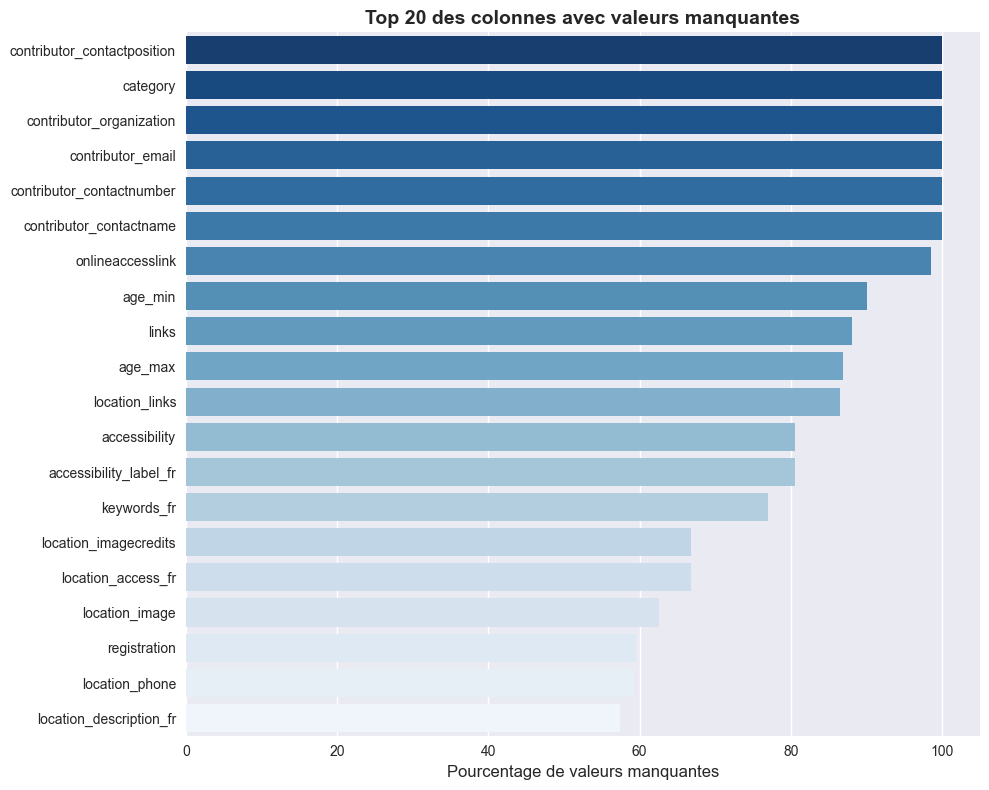

In [44]:
# Visualisation des valeurs manquantes (top 20)
top_missing = missing_stats[missing_stats["valeurs_manquantes"] > 0].head(20)

if len(top_missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.barplot(x=top_missing["pourcentage"], y=top_missing.index, palette="Blues_r", ax=ax)
    ax.set_xlabel("Pourcentage de valeurs manquantes", fontsize=12)
    ax.set_ylabel("")
    ax.set_title("Top 20 des colonnes avec valeurs manquantes", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">3. Analyse des champs essentiels pour le RAG</h2>

In [72]:
# Champs essentiels pour le chatbot
essential_fields = [
    "uid",
    "title_fr",
    "description_fr",
    "longdescription_fr",
    "keywords_fr",
    "daterange_fr",
    "firstdate_begin",
    "location_name",
    "location_city",
    "location_department",
    "canonicalurl"
]

print("=" * 50)
print("COMPLÉTUDE DES CHAMPS ESSENTIELS")
print("=" * 50)

completeness_data = []
for field in essential_fields:
    if field in df.columns:
        non_null = df[field].notna().sum()
        pct = (non_null / len(df) * 100)
        completeness_data.append({"champ": field, "complet": non_null, "pourcentage": pct})
        print(f"{field}: {non_null:,}/{len(df):,} ({pct:.2f}%)")
    else:
        print(f"{field}: COLONNE ABSENTE")

COMPLÉTUDE DES CHAMPS ESSENTIELS
uid: 9,962/9,962 (100.00%)
title_fr: 9,958/9,962 (99.96%)
description_fr: 9,958/9,962 (99.96%)
longdescription_fr: 9,605/9,962 (96.42%)
keywords_fr: 2,291/9,962 (23.00%)
daterange_fr: 9,962/9,962 (100.00%)
firstdate_begin: 9,962/9,962 (100.00%)
location_name: 9,962/9,962 (100.00%)
location_city: 9,954/9,962 (99.92%)
location_department: 9,739/9,962 (97.76%)
canonicalurl: 9,962/9,962 (100.00%)


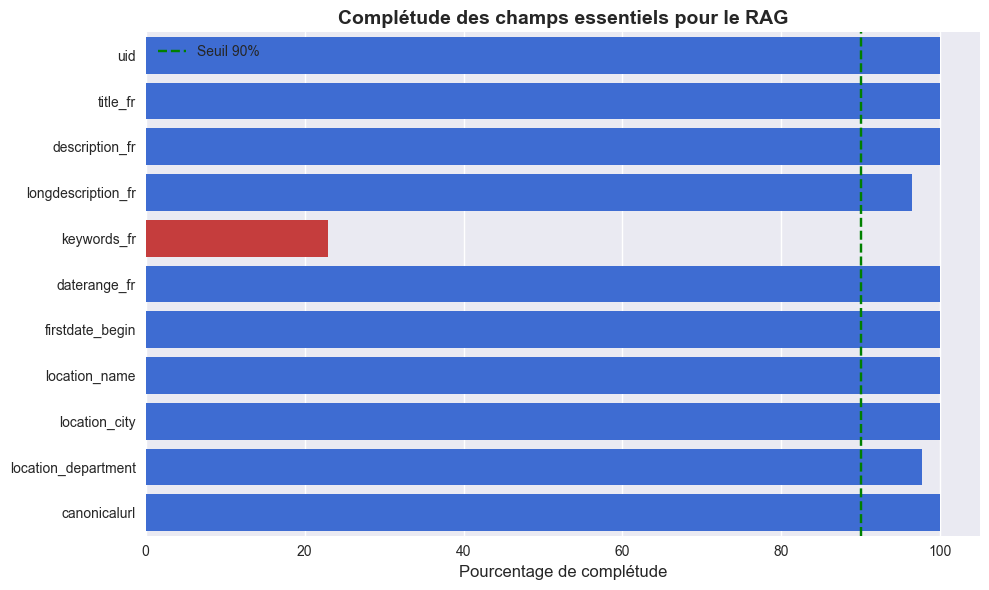

In [46]:
# Visualisation de la complétude
completeness_df = pd.DataFrame(completeness_data)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2563eb' if p >= 90 else '#f59e0b' if p >= 50 else '#dc2626' for p in completeness_df["pourcentage"]]
sns.barplot(x="pourcentage", y="champ", data=completeness_df, palette=colors, ax=ax)
ax.axvline(x=90, color='green', linestyle='--', label='Seuil 90%')
ax.set_xlabel("Pourcentage de complétude", fontsize=12)
ax.set_ylabel("")
ax.set_title("Complétude des champs essentiels pour le RAG", fontsize=14, fontweight="bold")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
plt.show()

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">4. Analyse des champs textuels</h2>

In [74]:
# Calcul des longueurs de texte
df["title_length"] = df["title_fr"].fillna("").str.len()
df["description_length"] = df["description_fr"].fillna("").str.len()
df["longdescription_length"] = df["longdescription_fr"].fillna("").str.len()

print("=" * 75)
print("STATISTIQUES SUR LES CHAMPS TEXTUELS - NOMBRES DE CARACTERES")
print("=" * 75)

print("\n--- Titres ---")
print(df["title_length"].describe())

print("\n--- Descriptions courtes ---")
print(df["description_length"].describe())

print("\n--- Descriptions longues ---")
print(df["longdescription_length"].describe())

STATISTIQUES SUR LES CHAMPS TEXTUELS - NOMBRES DE CARACTERES

--- Titres ---
count    9962.000000
mean       45.175266
std        25.202403
min         0.000000
25%        27.000000
50%        41.000000
75%        58.000000
max       150.000000
Name: title_length, dtype: float64

--- Descriptions courtes ---
count    9962.000000
mean       76.288496
std        67.006147
min         0.000000
25%        23.000000
50%        48.000000
75%       126.750000
max       200.000000
Name: description_length, dtype: float64

--- Descriptions longues ---
count    9962.000000
mean      703.663120
std       703.699249
min         0.000000
25%       271.000000
50%       523.000000
75%       908.000000
max      9952.000000
Name: longdescription_length, dtype: float64


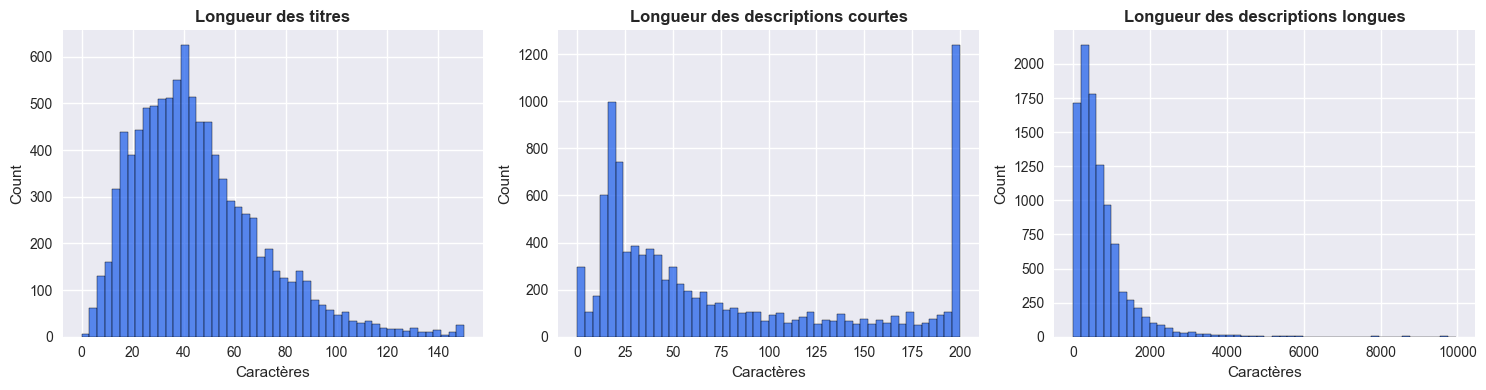

In [48]:
# Visualisation des longueurs de texte
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["title_length"], bins=50, color="#2563eb", ax=axes[0])
axes[0].set_title("Longueur des titres", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Caractères")

sns.histplot(df["description_length"], bins=50, color="#2563eb", ax=axes[1])
axes[1].set_title("Longueur des descriptions courtes", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Caractères")

sns.histplot(df["longdescription_length"], bins=50, color="#2563eb", ax=axes[2])
axes[2].set_title("Longueur des descriptions longues", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Caractères")

plt.tight_layout()
plt.show()

In [75]:
# Événements avec descriptions problématiques
short_desc = df[df["description_length"] < 20]
empty_desc = df[df["description_length"] == 0]

print("=" * 50)
print("QUALITÉ DES DESCRIPTIONS")
print("=" * 50)
print(f"Événements avec description < 20 caractères : {len(short_desc):,} ({len(short_desc)/len(df)*100:.1f}%)")
print(f"Événements sans description : {len(empty_desc):,} ({len(empty_desc)/len(df)*100:.2f}%)")

QUALITÉ DES DESCRIPTIONS
Événements avec description < 20 caractères : 2,178 (21.9%)
Événements sans description : 4 (0.04%)


In [50]:
# Exemples de descriptions très courtes
if len(short_desc) > 0:
    print("\n--- Exemples de descriptions courtes ---")
    sample = short_desc[["title_fr", "description_fr"]].head(5)
    for idx, row in sample.iterrows():
        print(f"  - {row['title_fr'][:50]}... : '{row['description_fr']}'")


--- Exemples de descriptions courtes ---
  - SALTI... : 'Spectacle de danse'
  - Joséphine Baker, le musical... : 'Comédie Musicale'
  - Bœuf à L’usine... : 'Bœuf à L’usine'
  - Concert d'1 Soir - Rhapsody in Blue... : 'Duo Argos'
  - Les Furtifs... : 'Les Furtifs'


<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">5. Analyse du contenu HTML</h2>

In [76]:
# Détection des balises HTML dans longdescription_fr

html_pattern = re.compile(r"<[^>]+>") # Motif Regex pour détecter les balises entre < >

# Crée un indicateur Vrai/Faux si une balise est trouvée
df["has_html"] = df["longdescription_fr"].fillna("").apply(
    lambda x: bool(html_pattern.search(x))
)

# Calcule le volume total de textes "pollués" par du HTML
html_count = df["has_html"].sum()

print("=" * 50)
print("ANALYSE DU CONTENU HTML")
print("=" * 50)
print(f"Événements avec HTML dans longdescription_fr : {html_count:,} ({html_count/len(df)*100:.1f}%)")

ANALYSE DU CONTENU HTML
Événements avec HTML dans longdescription_fr : 9,605 (96.4%)


In [52]:
# Types de balises HTML présentes
def extract_html_tags(text):
    if pd.isna(text):
        return []
    return list(set(re.findall(r"<([a-zA-Z0-9]+)[^>]*>", text)))

all_tags = []
for desc in df["longdescription_fr"].dropna():
    all_tags.extend(extract_html_tags(desc))

tag_counts = pd.Series(all_tags).value_counts()

print("\n--- Balises HTML les plus fréquentes ---")
print(tag_counts.head(15))


--- Balises HTML les plus fréquentes ---
p             9566
br            5853
strong        1926
a             1189
em            1133
h3             619
h2             503
li             283
ul             276
ol               7
h1               1
blockquote       1
Name: count, dtype: int64


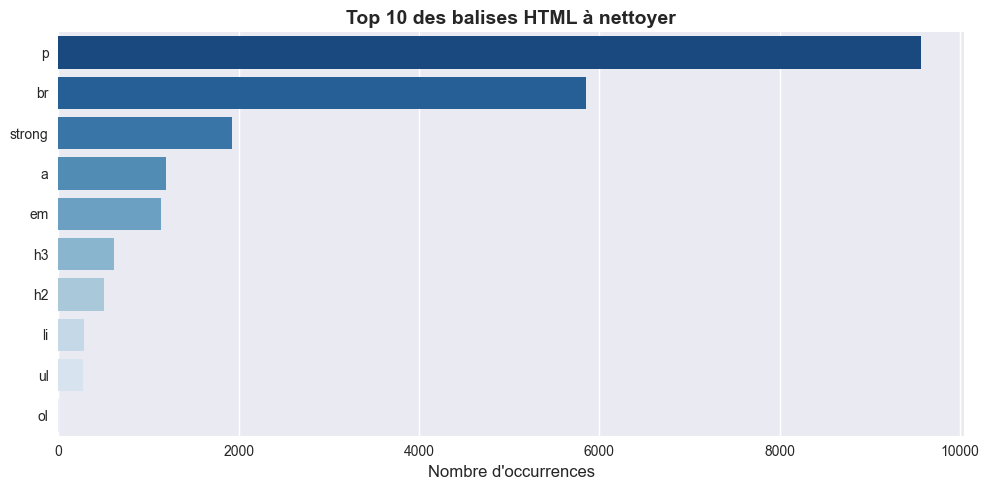

In [53]:
# Visualisation des balises HTML
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=tag_counts.head(10).values, y=tag_counts.head(10).index, palette="Blues_r", ax=ax)
ax.set_xlabel("Nombre d'occurrences", fontsize=12)
ax.set_ylabel("")
ax.set_title("Top 10 des balises HTML à nettoyer", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [54]:
# Exemple de description avec HTML
html_examples = df[df["has_html"]]["longdescription_fr"].iloc[:1].values[0]

print("\n--- Exemple de description avec HTML ---")
print(html_examples[:500] + "..." if len(html_examples) > 500 else html_examples)


--- Exemple de description avec HTML ---
<p><strong>Participez au concours ! Envoyez-vous vos poèmes, haïku, micro-fictions !</strong><br>Nous participons à l’opération « <strong>Dis-moi 10 mots pour la planète</strong> » du Ministère de la Culture, dans le cadre de la Semaine de la langue française, avec les 10 mots figurant</p>
<p>Dans ce cadre, nous vous proposons de nous envoyer vos poèmes, haïku, micro-fictions, en utilisant un ou plisieurs des 10 mots proposés dans leur liste :</p>
<ul>
<li><p>Biome</p>
</li>
<li><p>Butiner</p>
<...


<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">6. Analyse géographique</h2>

In [55]:
# Distribution par département
dept_counts = df["location_department"].value_counts()

print("=" * 50)
print("DISTRIBUTION PAR DÉPARTEMENT")
print("=" * 50)
print(dept_counts)

DISTRIBUTION PAR DÉPARTEMENT
location_department
Paris                2530
Seine-et-Marne       1454
Yvelines             1410
Hauts-de-Seine       1155
Seine-Saint-Denis     853
Essonne               840
Val-d'Oise            822
Val-de-Marne          583
Val-D'Oise             29
Seine-St-Denis         28
Seine-St.-Denis        11
Val-De-Marne            7
paris                   4
Métropole de Lyon       4
Île-de-France           2
Nord                    2
75010                   1
75011                   1
75008                   1
75012                   1
75018                   1
Name: count, dtype: int64


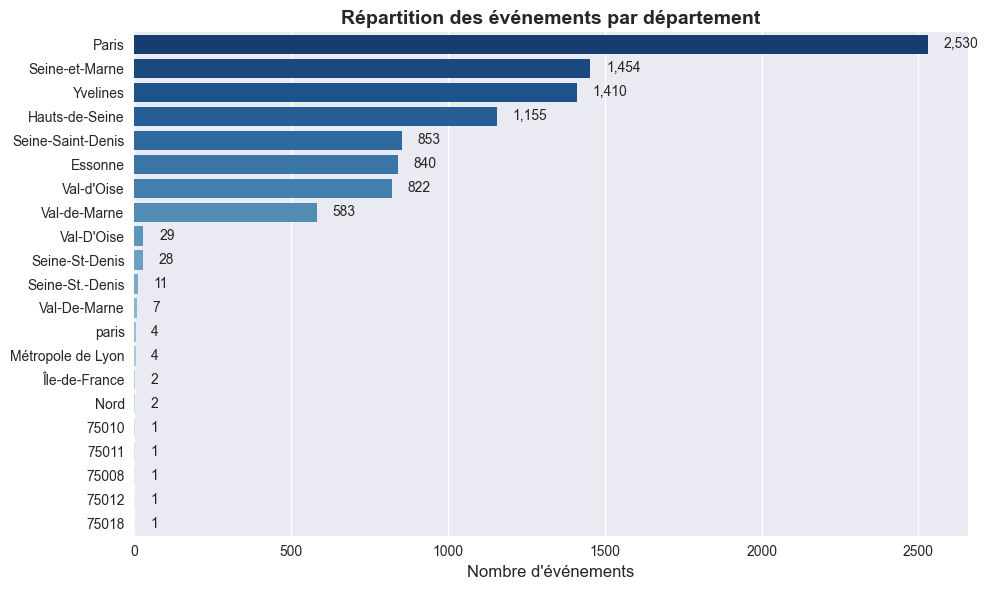

In [56]:
# Visualisation par département
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=dept_counts.values, y=dept_counts.index, palette="Blues_r", ax=ax)
ax.set_xlabel("Nombre d'événements", fontsize=12)
ax.set_ylabel("")
ax.set_title("Répartition des événements par département", fontsize=14, fontweight="bold")

# Ajout des valeurs sur les barres
for i, v in enumerate(dept_counts.values):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [57]:
# Top 15 des villes
city_counts = df["location_city"].value_counts().head(15)

print("\n" + "=" * 50)
print("TOP 15 DES VILLES")
print("=" * 50)
print(city_counts)


TOP 15 DES VILLES
location_city
Paris                    2609
Fontainebleau             303
Versailles                204
PARIS                     153
Boulogne-Billancourt      152
Montreuil                 131
Saint-Germain-en-Laye     122
Saint-Denis               111
Issy-les-Moulineaux        94
Pontoise                   89
Nanterre                   78
Corbeil-Essonnes           70
Courbevoie                 69
Meudon                     68
Argenteuil                 64
Name: count, dtype: int64


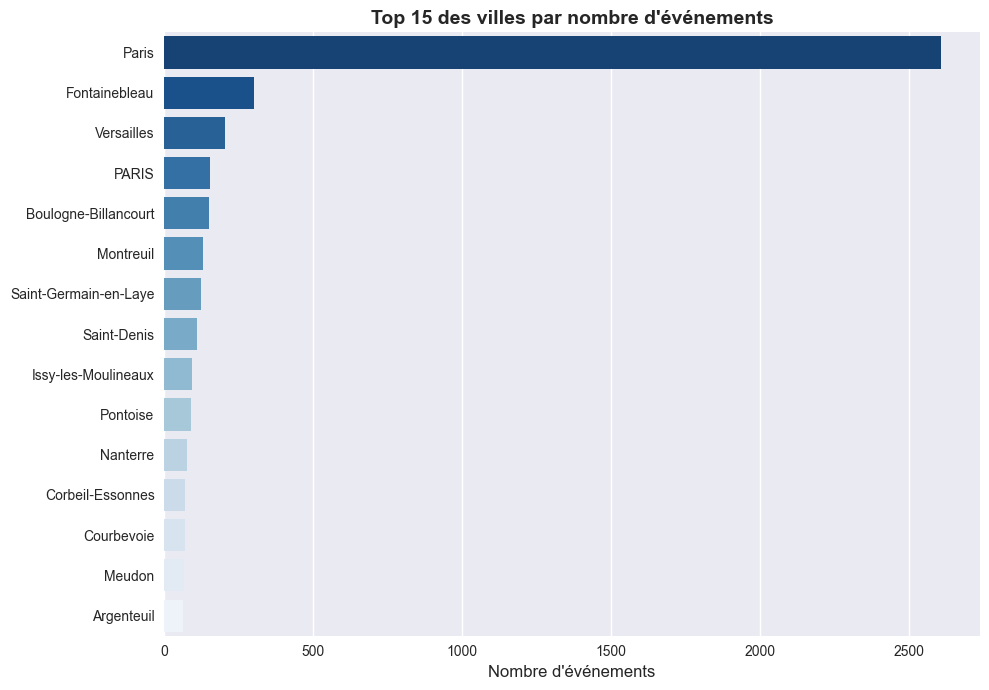

In [58]:
# Visualisation top 15 villes
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=city_counts.values, y=city_counts.index, palette="Blues_r", ax=ax)
ax.set_xlabel("Nombre d'événements", fontsize=12)
ax.set_ylabel("")
ax.set_title("Top 15 des villes par nombre d'événements", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">7. Analyse temporelle</h2>

In [77]:
# Conversion des dates
df["firstdate_begin_dt"] = pd.to_datetime(df["firstdate_begin"], errors="coerce")

print("=" * 50)
print("PLAGE TEMPORELLE DES ÉVÉNEMENTS")
print("=" * 50)
print(f"Date minimum : {df['firstdate_begin_dt'].min()}")
print(f"Date maximum : {df['firstdate_begin_dt'].max()}")

PLAGE TEMPORELLE DES ÉVÉNEMENTS
Date minimum : 2025-01-01 23:00:00+00:00
Date maximum : 2026-11-21 19:00:00+00:00


In [60]:
# Distribution par mois
df["month"] = df["firstdate_begin_dt"].dt.to_period("M")
monthly_counts = df["month"].value_counts().sort_index()

print("\n--- Distribution par mois ---")
print(monthly_counts)


--- Distribution par mois ---
month
2025-01     124
2025-02     139
2025-03     301
2025-04      58
2025-05     760
2025-06    1509
2025-07     911
2025-08     291
2025-09    3717
2025-10     823
2025-11     737
2025-12     188
2026-01     139
2026-02     119
2026-03      65
2026-04      30
2026-05      35
2026-06      12
2026-10       2
2026-11       2
Freq: M, Name: count, dtype: int64


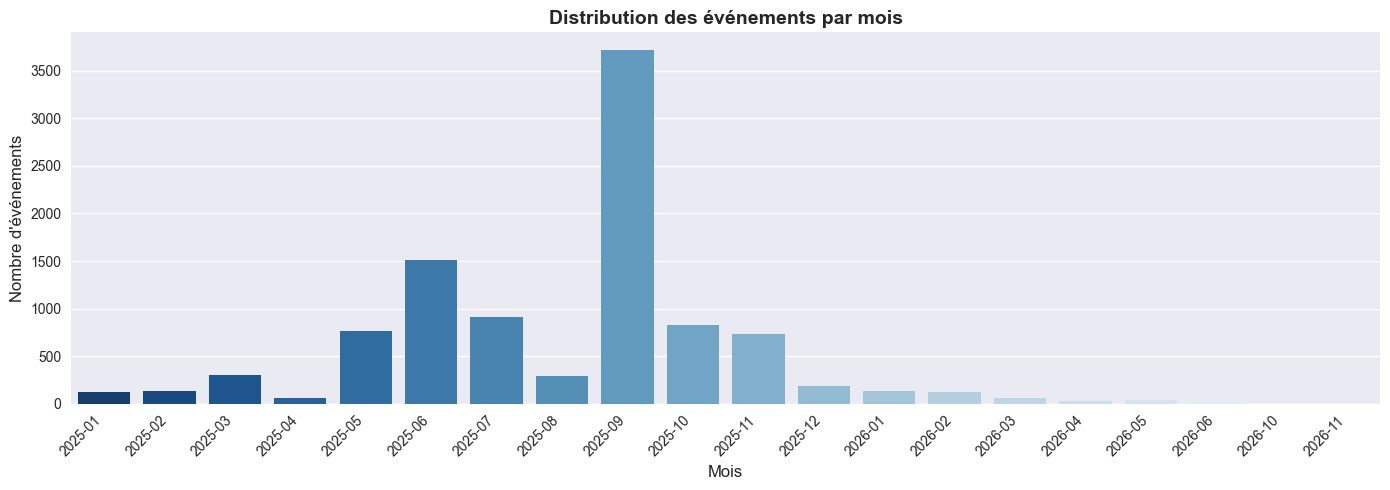

In [61]:
# Visualisation temporelle
fig, ax = plt.subplots(figsize=(14, 5))

x_labels = [str(m) for m in monthly_counts.index]
sns.barplot(x=x_labels, y=monthly_counts.values, palette="Blues_r", ax=ax)

ax.set_xlabel("Mois", fontsize=12)
ax.set_ylabel("Nombre d'événements", fontsize=12)
ax.set_title("Distribution des événements par mois", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

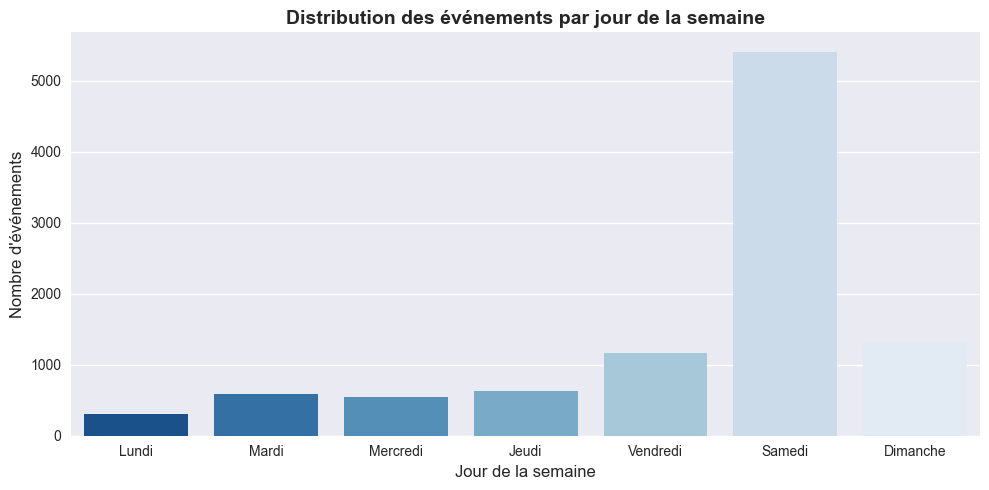

In [84]:
# Distribution par jour de la semaine

df["day_of_week"] = df["firstdate_begin_dt"].dt.day_name()
day_order_en = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

traduction = {
    "Monday": "Lundi", "Tuesday": "Mardi", "Wednesday": "Mercredi",
    "Thursday": "Jeudi", "Friday": "Vendredi", "Saturday": "Samedi", "Sunday": "Dimanche"
}

# Calcul et renommage
day_counts = df["day_of_week"].value_counts().reindex(day_order_en)
day_counts.index = day_counts.index.map(traduction) # On remplace les noms ici

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette="Blues_r", ax=ax)
ax.set_xlabel("Jour de la semaine", fontsize=12)
ax.set_ylabel("Nombre d'événements", fontsize=12)
ax.set_title("Distribution des événements par jour de la semaine", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">8. Analyse des mots-clés</h2>

In [63]:
# Événements avec mots-clés
has_keywords = df["keywords_fr"].notna() & df["keywords_fr"].apply(
    lambda x: len(x) > 0 if isinstance(x, list) else False
)

print("=" * 50)
print("ANALYSE DES MOTS-CLÉS")
print("=" * 50)
print(f"Événements avec mots-clés : {has_keywords.sum():,} ({has_keywords.sum()/len(df)*100:.1f}%)")

ANALYSE DES MOTS-CLÉS
Événements avec mots-clés : 2,291 (23.0%)


In [64]:
# Extraction de tous les mots-clés
all_keywords = []
for keywords in df["keywords_fr"].dropna():
    if isinstance(keywords, list):
        all_keywords.extend(keywords)

keyword_counts = pd.Series(all_keywords).value_counts()

print("\n--- Top 20 des mots-clés ---")
print(keyword_counts.head(20))


--- Top 20 des mots-clés ---
Jazz                      160
musique                   142
concert                   139
La semaine du Tourisme    104
jeune public              102
théâtre                   100
Théâtre                    99
industrie                  81
xls2410                    74
Recrutement                74
en physique                69
nature                     68
spectacle                  67
Tout public                65
jardin                     64
orientation                61
#TousMobilisés             61
histoire                   57
danse                      56
atelier                    55
Name: count, dtype: int64


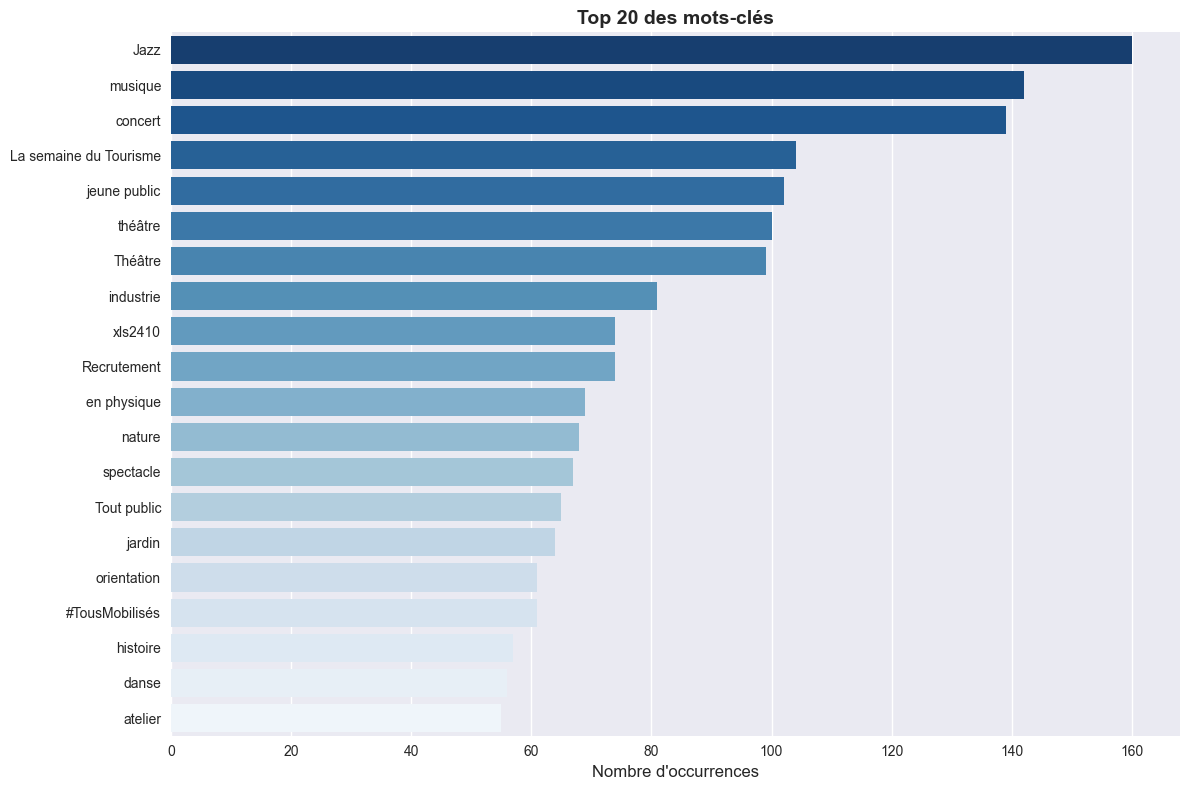

In [65]:
# Visualisation des mots-clés
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(x=keyword_counts.head(20).values, y=keyword_counts.head(20).index, palette="Blues_r", ax=ax)
ax.set_xlabel("Nombre d'occurrences", fontsize=12)
ax.set_ylabel("")
ax.set_title("Top 20 des mots-clés", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">9. Analyse des champs JSON à parser</h2>

In [ ]:
# Champs contenant du JSON en string
# cartographier la richesse des données (Métadonnées de la collecte)
json_fields = ["timings", "attendancemode", "status", "registration", "links"]

print("=" * 50)
print("CHAMPS JSON À PARSER")
print("=" * 50)
for field in json_fields:
    if field in df.columns:
        non_null = df[field].notna().sum()
        print(f"{field}: {non_null:,} valeurs non nulles ({non_null/len(df)*100:.1f}%)")

CHAMPS JSON À PARSER
timings: 9,962 valeurs non nulles (100.0%)
attendancemode: 9,962 valeurs non nulles (100.0%)
status: 9,962 valeurs non nulles (100.0%)
registration: 4,032 valeurs non nulles (40.5%)
links: 1,189 valeurs non nulles (11.9%)


In [67]:
# Exemple de parsing du champ timings
sample_timings = df["timings"].dropna().iloc[0]

print("\n--- Exemple de timings (brut) ---")
print(sample_timings[:200] + "..." if len(sample_timings) > 200 else sample_timings)

# Parsing
parsed_timings = json.loads(sample_timings)
print(f"\nNombre de créneaux : {len(parsed_timings)}")
print(f"Premier créneau : {parsed_timings[0]}")


--- Exemple de timings (brut) ---
[{"begin": "2025-01-02T00:00:00+01:00", "end": "2025-01-02T23:59:00+01:00"}, {"begin": "2025-01-03T00:00:00+01:00", "end": "2025-01-03T23:29:00+01:00"}, {"begin": "2025-01-04T00:00:00+01:00", "end": "...

Nombre de créneaux : 165
Premier créneau : {'begin': '2025-01-02T00:00:00+01:00', 'end': '2025-01-02T23:59:00+01:00'}


In [68]:
# Exemple de parsing du champ attendancemode
sample_attendance = df["attendancemode"].dropna().iloc[0]

print("\n--- Exemple de attendancemode (brut) ---")
print(sample_attendance)

# Parsing
parsed_attendance = json.loads(sample_attendance)
print(f"\nParsé : {parsed_attendance}")


--- Exemple de attendancemode (brut) ---
{"id": 3, "label": {"fr": "Mixte", "en": "Mixed", "it": "Mista", "es": "Mezclado", "de": "Gemischt", "br": "Kemmesk", "io": "crwdns14270:0crwdne14270:0", "oc": "Mesclat"}}

Parsé : {'id': 3, 'label': {'fr': 'Mixte', 'en': 'Mixed', 'it': 'Mista', 'es': 'Mezclado', 'de': 'Gemischt', 'br': 'Kemmesk', 'io': 'crwdns14270:0crwdne14270:0', 'oc': 'Mesclat'}}


<h2 style="color: #1e40af; background-color: #eff6ff; padding: 10px; border-left: 4px solid #3b82f6; margin: 15px 0; font-weight: bold;">10. Synthèse et recommandations de nettoyage</h2>

In [85]:
print("=" * 70)
print("                    SYNTHÈSE DE L'EXPLORATION                         ")
print("=" * 70)

print(f"\nNombre total d'événements : {len(df):,}")

print("\n" + "-" * 40)
print("QUALITÉ DES DONNÉES")
print("-" * 40)
print(f"  - Événements avec titre         : {df['title_fr'].notna().sum():,} ({df['title_fr'].notna().sum()/len(df)*100:.2f}%)")
print(f"  - Événements avec description   : {(df['description_length'] > 0).sum():,} ({(df['description_length'] > 0).sum()/len(df)*100:.2f}%)")
print(f"  - Événements avec mots-clés     : {has_keywords.sum():,} ({has_keywords.sum()/len(df)*100:.2f}%)")
print(f"  - Événements avec HTML à nettoyer : {html_count:,} ({html_count/len(df)*100:.2f}%)")

print("\n" + "-" * 40)
print("RECOMMANDATIONS DE NETTOYAGE")
print("-" * 40)
print("  1. Supprimer les balises HTML de longdescription_fr")
print("  2. Parser les champs JSON : timings, attendancemode, status, registration, links")
print("  3. Filtrer les événements sans titre ou description")
print("  4. Normaliser les dates au format ISO")
print("  5. Créer un champ text_for_embedding combinant les informations clés")

                    SYNTHÈSE DE L'EXPLORATION                         

Nombre total d'événements : 9,962

----------------------------------------
QUALITÉ DES DONNÉES
----------------------------------------
  - Événements avec titre         : 9,958 (99.96%)
  - Événements avec description   : 9,958 (99.96%)
  - Événements avec mots-clés     : 2,291 (23.00%)
  - Événements avec HTML à nettoyer : 9,605 (96.42%)

----------------------------------------
RECOMMANDATIONS DE NETTOYAGE
----------------------------------------
  1. Supprimer les balises HTML de longdescription_fr
  2. Parser les champs JSON : timings, attendancemode, status, registration, links
  3. Filtrer les événements sans titre ou description
  4. Normaliser les dates au format ISO
  5. Créer un champ text_for_embedding combinant les informations clés


In [86]:
# Résumé sous forme de tableau
summary_data = {
    "Métrique": [
        "Total événements",
        "Avec titre",
        "Avec description",
        "Avec mots-clés",
        "Avec HTML à nettoyer",
        "Départements couverts",
        "Villes couvertes"
    ],
    "Valeur": [
        f"{len(df):,}",
        f"{df['title_fr'].notna().sum():,}",
        f"{(df['description_length'] > 0).sum():,}",
        f"{has_keywords.sum():,}",
        f"{html_count:,}",
        f"{df['location_department'].nunique()}",
        f"{df['location_city'].nunique()}"
    ],
    "Pourcentage": [
        "100%",
        f"{df['title_fr'].notna().sum()/len(df)*100:.2f}%",
        f"{(df['description_length'] > 0).sum()/len(df)*100:.2f}%",
        f"{has_keywords.sum()/len(df)*100:.2f}%",
        f"{html_count/len(df)*100:.2f}%",
        "-",
        "-"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))



             Métrique Valeur Pourcentage
     Total événements  9,962        100%
           Avec titre  9,958      99.96%
     Avec description  9,958      99.96%
       Avec mots-clés  2,291      23.00%
 Avec HTML à nettoyer  9,605      96.42%
Départements couverts     21           -
     Villes couvertes    700           -


In [87]:
# Sauvegarde des statistiques pour référence
stats_summary = {
    "total_events": len(df),
    "events_with_title": int(df["title_fr"].notna().sum()),
    "events_with_description": int((df["description_length"] > 0).sum()),
    "events_with_keywords": int(has_keywords.sum()),
    "events_with_html": int(html_count),
    "departments": dept_counts.to_dict(),
    "top_cities": city_counts.to_dict(),
    "top_keywords": keyword_counts.head(20).to_dict()
}

# Sauvegarde
stats_path = Path("../src/data/processed/exploration_stats.json")
stats_path.parent.mkdir(parents=True, exist_ok=True)

with open(stats_path, "w", encoding="utf-8") as f:
    json.dump(stats_summary, f, ensure_ascii=False, indent=2, default=str)

print(f"\nStatistiques sauvegardées dans : {stats_path}")


Statistiques sauvegardées dans : ../src/data/processed/exploration_stats.json
